# PayShield AI — Exploratory Data Analysis

## Objective

Explore the synthetic payment transaction dataset and identify
patterns associated with payment failures and bank/service degradation.

We will investigate:

1. Dataset structure
2. Missing values
3. Payment success/failure distribution
4. Bank-wise payment performance
5. Failure reasons
6. Transaction latency
7. Bank health and payment success
8. Payment failures over time
9. Signs of emerging incidents

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("../data/raw/transactions.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 12)


In [31]:
df.head()

,transaction_id,timestamp,amount,sender_bank,receiver_bank,payment_method,upi_app,bank_health,latency_ms,payment_status,timeout,error_code
0,TXN0000001,2026-01-01 00:01:39,345.00,AXIS,AXIS,UPI,PhonePe,NORMAL,1447.70,SUCCESS,0,NONE
1,TXN0000002,2026-01-01 00:07:00,2940.21,ICICI,KOTAK,UPI,BHIM,NORMAL,956.22,SUCCESS,0,NONE
2,TXN0000003,2026-01-01 00:17:34,219.04,INDUSIND,PNB,UPI,PhonePe,NORMAL,1132.68,SUCCESS,0,NONE
3,TXN0000004,2026-01-01 00:20:44,232.49,AXIS,INDUSIND,UPI,Paytm,NORMAL,1788.86,SUCCESS,0,NONE
4,TXN0000005,2026-01-01 00:35:07,590.03,INDUSIND,PNB,UPI,PhonePe,NORMAL,610.46,SUCCESS,0,NONE


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   transaction_id  100000 non-null  object        
 1   timestamp       100000 non-null  datetime64[ns]
 2   amount          100000 non-null  float64       
 3   sender_bank     100000 non-null  object        
 4   receiver_bank   100000 non-null  object        
 5   payment_method  100000 non-null  object        
 6   upi_app         100000 non-null  object        
 7   bank_health     100000 non-null  object        
 8   latency_ms      100000 non-null  float64       
 9   payment_status  100000 non-null  object        
 10  timeout         100000 non-null  int64         
 11  error_code      100000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 9.2+ MB


In [33]:
df.describe()

,timestamp,amount,latency_ms,timeout
count,100000,100000.000000,100000.000000,100000.000000
mean,2026-01-16 02:49:39.476620288,667.070818,1132.545411,0.021610
min,2026-01-01 00:01:39,6.650000,205.650000,0.000000
25%,2026-01-08 16:13:40.750000128,205.005000,808.595000,0.000000
50%,2026-01-15 22:53:19.500000,403.255000,1044.500000,0.000000
75%,2026-01-23 16:08:25,793.647500,1351.137500,0.000000
max,2026-01-30 23:59:12,50773.040000,13350.740000,1.000000
std,NaN,888.276076,489.723451,0.145407


In [34]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
transaction_id    0
timestamp         0
amount            0
sender_bank       0
receiver_bank     0
payment_method    0
upi_app           0
bank_health       0
latency_ms        0
payment_status    0
timeout           0
error_code        0
dtype: int64


In [35]:
duplicates = df["transaction_id"].duplicated().sum()

print("Duplicate transaction IDs:", duplicates)

Duplicate transaction IDs: 0


In [ ]:
payment_counts = df["payment_status"].value_counts()

print(payment_counts)

payment_status
SUCCESS    97243
FAILED      2757
Name: count, dtype: int64


In [57]:
payment_percentages = (
    df["payment_status"]
    .value_counts(normalize=True)
    * 100
)

print(payment_percentages)

payment_status
SUCCESS    97.243
FAILED      2.757
Name: proportion, dtype: float64


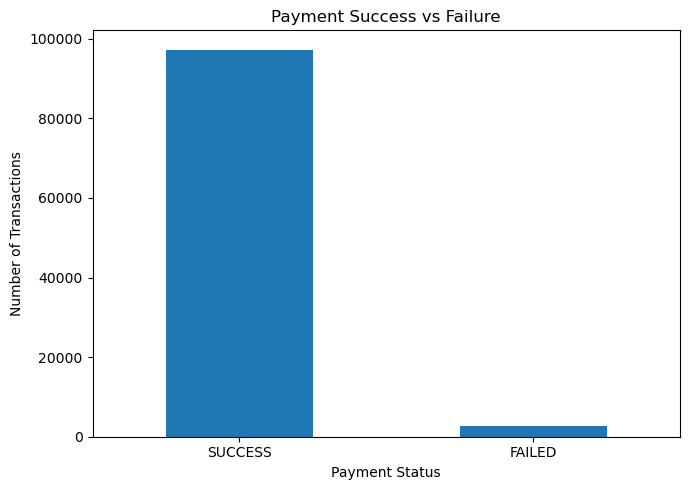

In [66]:
plt.figure(figsize=(7, 5))

status_counts.plot(kind="bar")

plt.title("Payment Success vs Failure")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [39]:
failed_df = df[df["payment_status"] == "FAILED"]

failure_counts = failed_df["error_code"].value_counts()

print(failure_counts)

error_code
BANK_SERVER_ERROR     709
BANK_TIMEOUT          693
NETWORK_TIMEOUT       518
INSUFFICIENT_FUNDS    320
MERCHANT_ERROR        282
INVALID_UPI           235
Name: count, dtype: int64


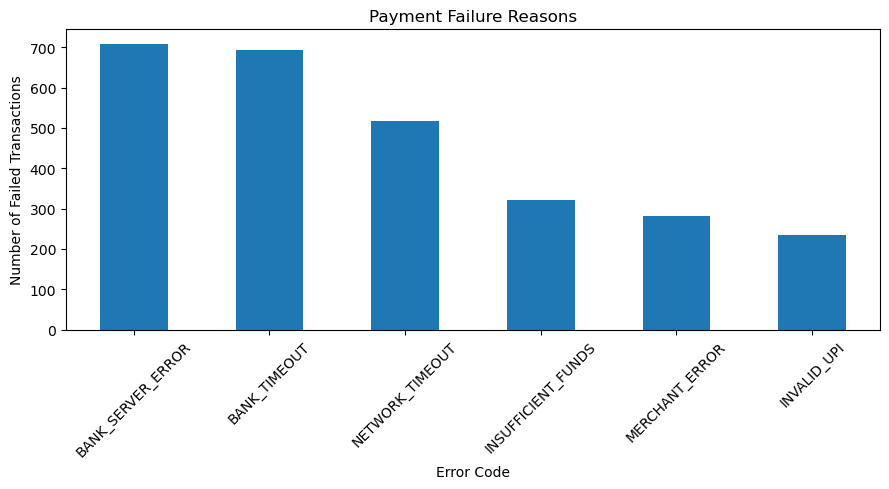

In [40]:
plt.figure(figsize=(9, 5))

failure_counts.plot(kind="bar")

plt.title("Payment Failure Reasons")
plt.xlabel("Error Code")
plt.ylabel("Number of Failed Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
bank_success = (
    df.groupby("receiver_bank")["payment_status"]
    .apply(lambda x: (x == "SUCCESS").mean() * 100)
    .sort_values()
)

print(bank_success)

receiver_bank
HDFC        96.772271
AXIS        96.942791
ICICI       96.960178
KOTAK       96.966068
SBI         97.131434
CANARA      97.415089
BOB         97.510000
INDUSIND    97.565080
PNB         97.568026
IDFC        97.592167
Name: payment_status, dtype: float64


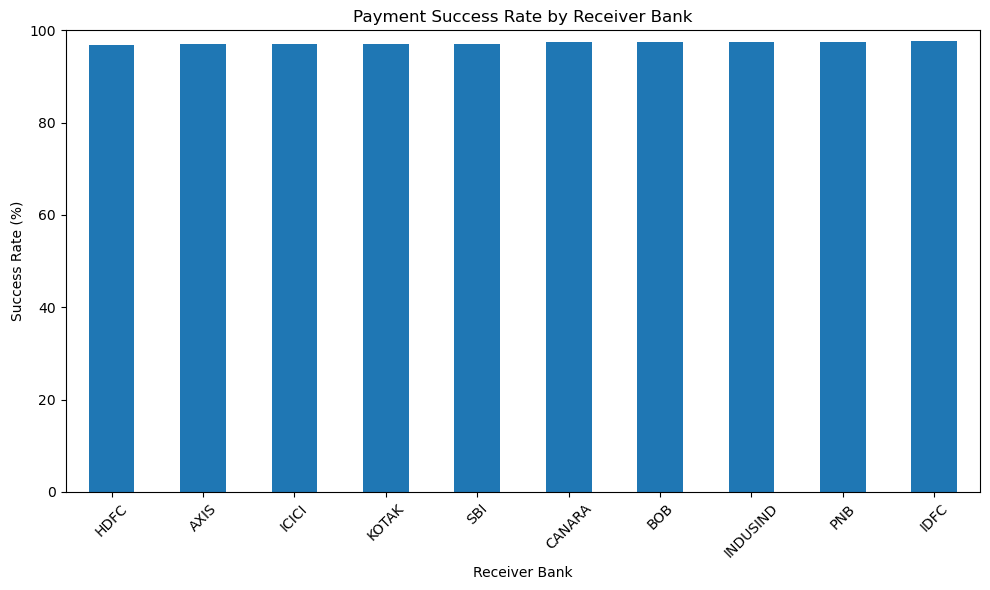

In [42]:
plt.figure(figsize=(10, 6))

bank_success.plot(kind="bar")

plt.title("Payment Success Rate by Receiver Bank")
plt.xlabel("Receiver Bank")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [43]:
print(df["latency_ms"].describe())

count    100000.000000
mean       1132.545411
std         489.723451
min         205.650000
25%         808.595000
50%        1044.500000
75%        1351.137500
max       13350.740000
Name: latency_ms, dtype: float64


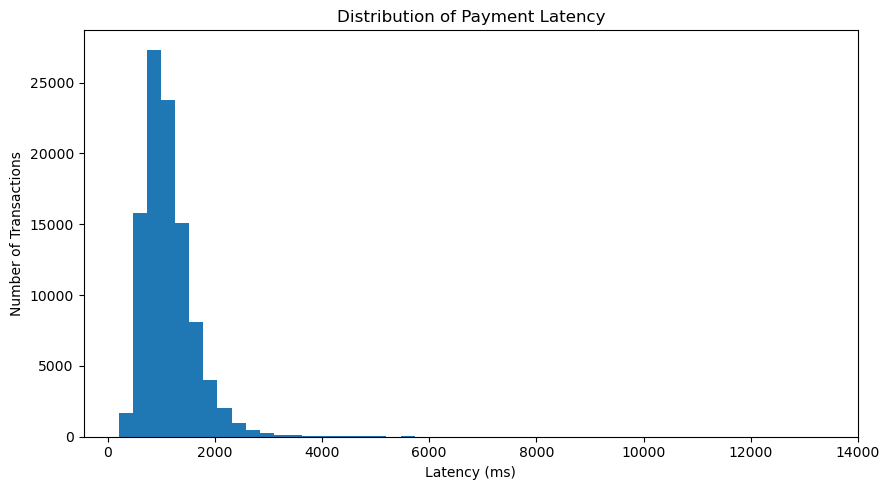

In [44]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["latency_ms"],
    bins=50
)

plt.title("Distribution of Payment Latency")
plt.xlabel("Latency (ms)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

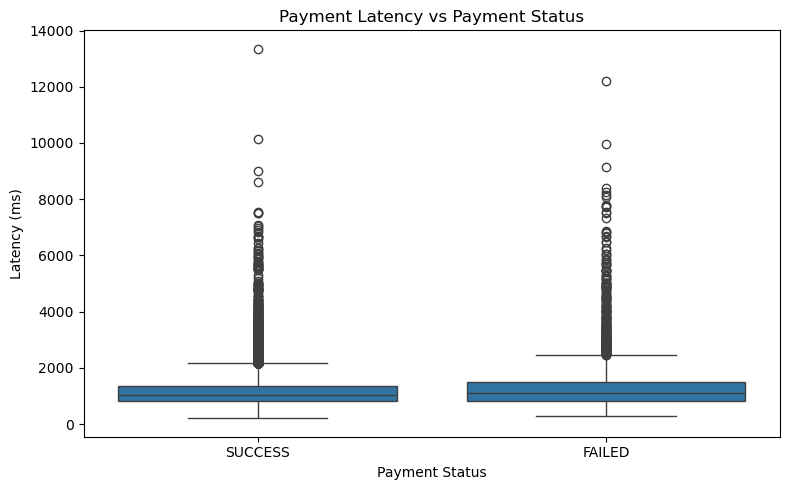

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="payment_status",
    y="latency_ms"
)

plt.title("Payment Latency vs Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Latency (ms)")

plt.tight_layout()
plt.show()

In [46]:
health_counts = df["bank_health"].value_counts()

print(health_counts)

bank_health
NORMAL      99194
SEVERE        397
RECOVERY      240
DEGRADED      169
Name: count, dtype: int64


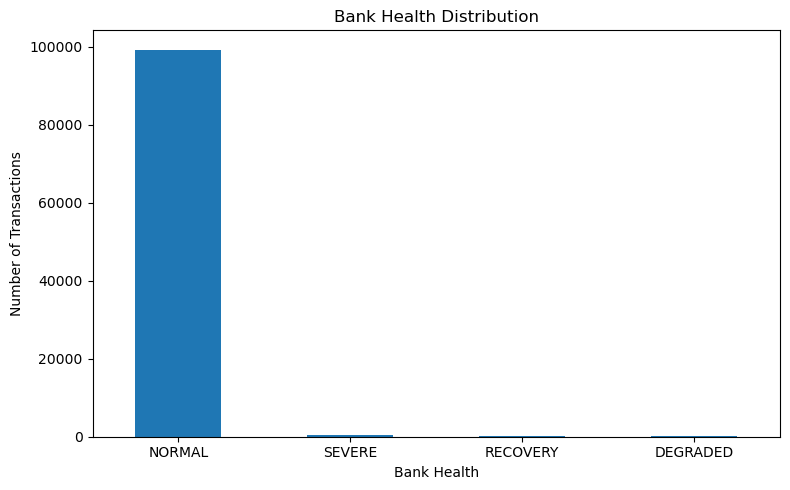

In [47]:
plt.figure(figsize=(8, 5))

health_counts.plot(kind="bar")

plt.title("Bank Health Distribution")
plt.xlabel("Bank Health")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
health_success = (
    df.groupby("bank_health")["payment_status"]
    .apply(lambda x: (x == "SUCCESS").mean() * 100)
)

print("Payment success rate by bank health:")
print(health_success)

Payment success rate by bank health:
bank_health
DEGRADED    82.248521
NORMAL      97.490776
RECOVERY    88.750000
SEVERE      46.851385
Name: payment_status, dtype: float64


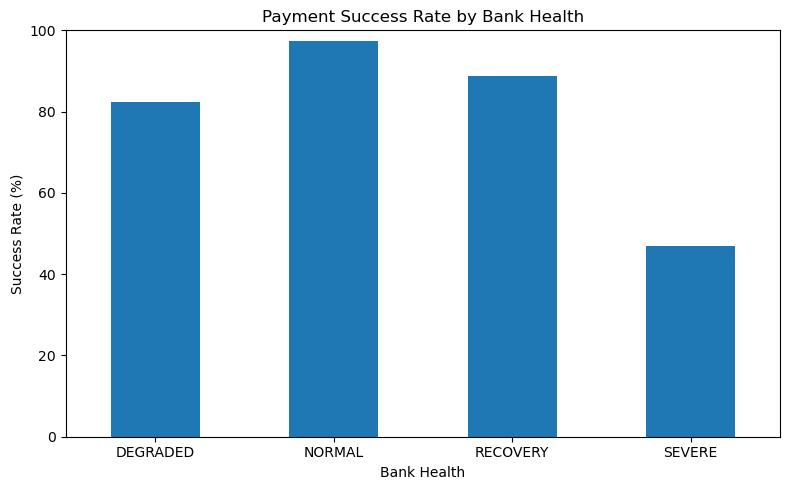

In [49]:
plt.figure(figsize=(8, 5))

health_success.plot(kind="bar")

plt.title("Payment Success Rate by Bank Health")
plt.xlabel("Bank Health")
plt.ylabel("Success Rate (%)")

plt.ylim(0, 100)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [58]:
timeout_rate = df["timeout"].mean() * 100

print(
    f"Overall timeout rate: {timeout_rate:.2f}%"
)

Overall timeout rate: 2.16%


In [50]:
timeout_rate = (
    df.groupby("bank_health")["timeout"]
    .mean()
    * 100
)

print("Timeout rate by bank health:")
print(timeout_rate)

Timeout rate by bank health:
bank_health
DEGRADED     8.875740
NORMAL       2.014235
RECOVERY     4.583333
SEVERE      34.508816
Name: timeout, dtype: float64


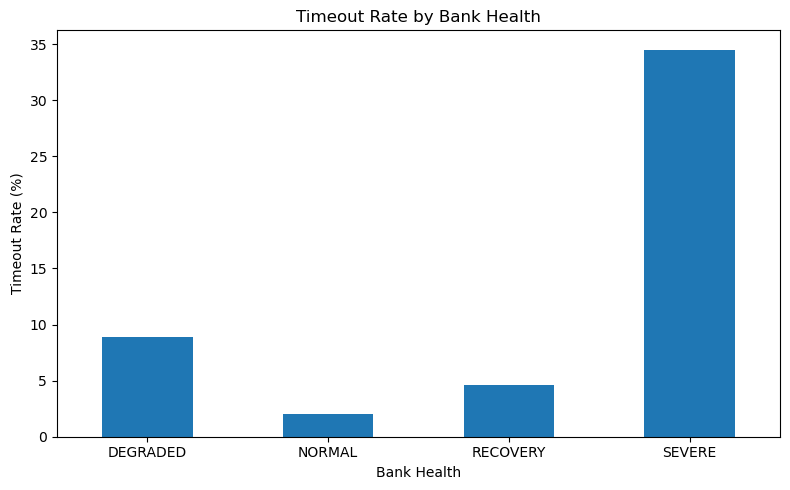

In [51]:
plt.figure(figsize=(8, 5))

timeout_rate.plot(kind="bar")

plt.title("Timeout Rate by Bank Health")
plt.xlabel("Bank Health")
plt.ylabel("Timeout Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [61]:
sbi = df[
    df["receiver_bank"] == "SBI"
].copy()

print("SBI transactions:", len(sbi))

SBI transactions: 10005


In [62]:
sbi["time_window"] = (
    sbi["timestamp"]
    .dt.floor("30min")
)

In [63]:
sbi_monitoring = (
    sbi.groupby("time_window")
    .agg(
        transaction_count=(
            "transaction_id",
            "count"
        ),

        success_rate=(
            "payment_status",
            lambda x:
            (x == "SUCCESS").mean() * 100
        ),

        avg_latency=(
            "latency_ms",
            "mean"
        ),

        timeout_rate=(
            "timeout",
            "mean"
        )
    )
    .reset_index()
)

sbi_monitoring.head()

,time_window,transaction_count,success_rate,avg_latency,timeout_rate
0,2026-01-01 00:30:00,2,50.0,1126.915,0.0
1,2026-01-01 01:30:00,2,100.0,1512.125,0.0
2,2026-01-01 02:00:00,1,100.0,490.540,0.0
3,2026-01-01 02:30:00,1,100.0,1219.250,0.0
4,2026-01-01 03:00:00,1,100.0,1282.850,0.0


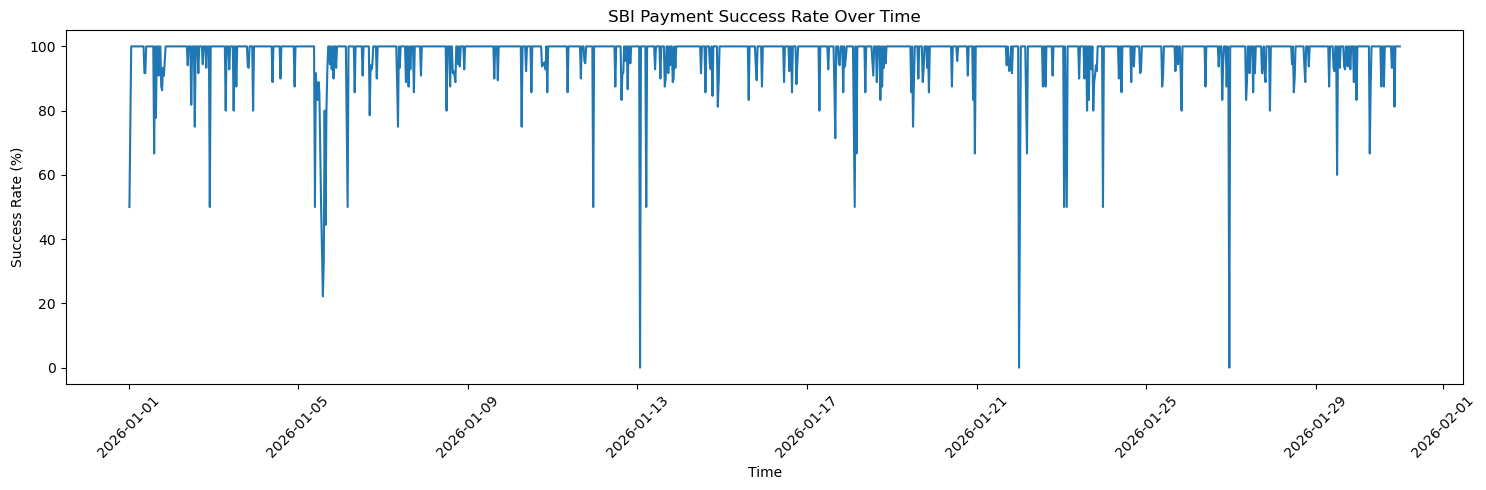

In [64]:
plt.figure(figsize=(15, 5))

plt.plot(
    sbi_monitoring["time_window"],
    sbi_monitoring["success_rate"]
)

plt.title(
    "SBI Payment Success Rate Over Time"
)

plt.xlabel("Time")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

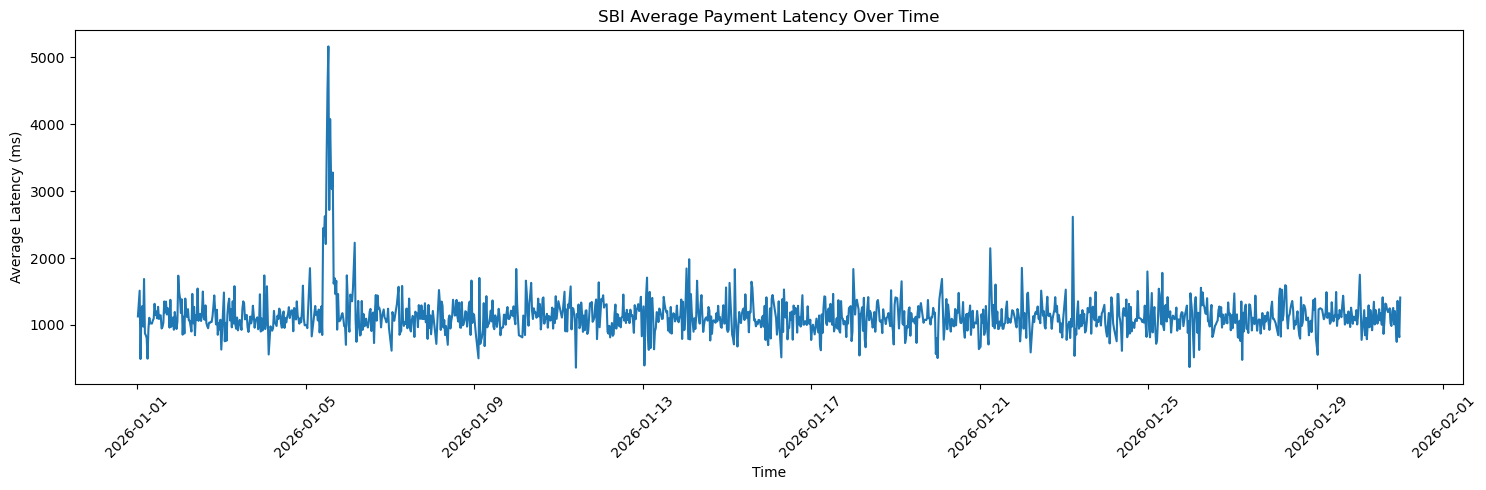

In [65]:
plt.figure(figsize=(15, 5))

plt.plot(
    sbi_monitoring["time_window"],
    sbi_monitoring["avg_latency"]
)

plt.title(
    "SBI Average Payment Latency Over Time"
)

plt.xlabel("Time")
plt.ylabel("Average Latency (ms)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

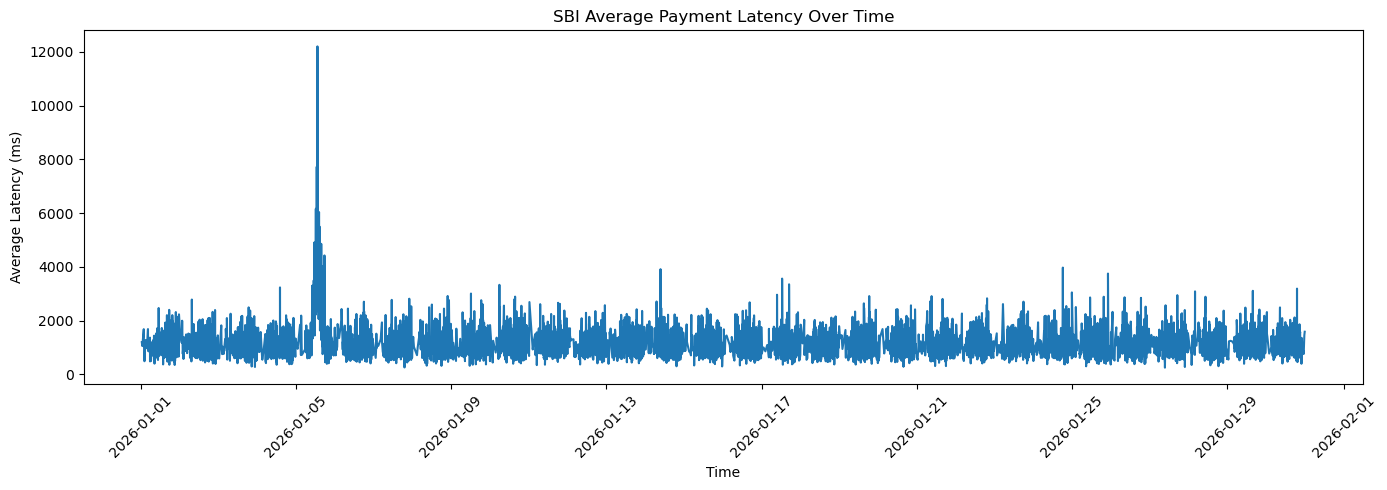

In [54]:
plt.figure(figsize=(14, 5))

plt.plot(
    sbi_minute["minute"],
    sbi_minute["avg_latency"]
)

plt.title("SBI Average Payment Latency Over Time")
plt.xlabel("Time")
plt.ylabel("Average Latency (ms)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
df["date"] = df["timestamp"].dt.date

daily_volume = (
    df.groupby("date")
    .size()
)

print(daily_volume)

date
2026-01-01    3409
2026-01-02    3301
2026-01-03    3270
2026-01-04    3333
2026-01-05    3408
2026-01-06    3339
2026-01-07    3298
2026-01-08    3388
2026-01-09    3276
2026-01-10    3285
2026-01-11    3376
2026-01-12    3370
2026-01-13    3294
2026-01-14    3405
2026-01-15    3320
2026-01-16    3399
2026-01-17    3309
2026-01-18    3396
2026-01-19    3306
2026-01-20    3317
2026-01-21    3352
2026-01-22    3240
2026-01-23    3362
2026-01-24    3274
2026-01-25    3269
2026-01-26    3411
2026-01-27    3337
2026-01-28    3365
2026-01-29    3351
2026-01-30    3240
dtype: int64


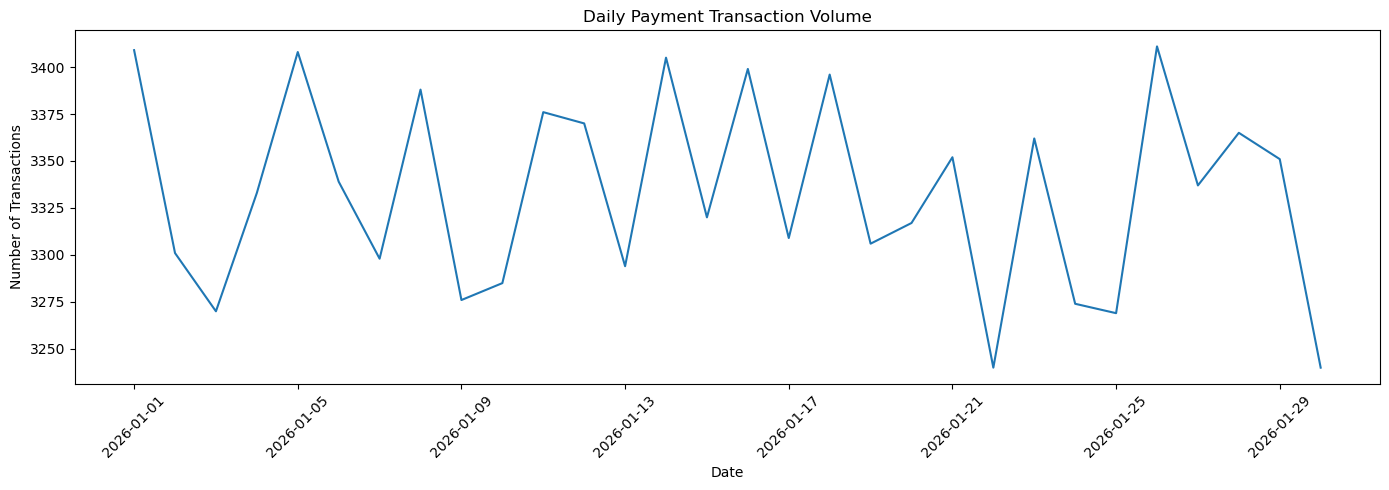

In [60]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_volume.index,
    daily_volume.values
)

plt.title("Daily Payment Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [55]:
df.to_csv(
    "../data/processed/transactions_eda.csv",
    index=False
)

print("Processed dataset saved!")

Processed dataset saved!
